<a href="https://colab.research.google.com/github/Lingeshkumar24-code/NLP-projects/blob/main/NLP_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from textblob import TextBlob
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
reviews = [

"The food was delicious and served hot",
"Excellent taste and quick delivery",
"Loved the packaging and food quality",
"Amazing customer service and tasty food",
"The pizza was fresh and very flavorful",
"Delivery arrived on time and food was great",
"Highly recommend this restaurant",
"Affordable prices and excellent quality",
"The burger was juicy and delicious",
"Fast delivery and friendly staff",

"Food was cold when it arrived",
"Delivery was very late",
"Poor packaging caused food to spill",
"The food tasted stale and bad",
"Customer service was rude",
"Very expensive for the quality provided",
"Order was delayed by more than an hour",
"The burger was burnt and dry",
"Packaging was damaged during delivery",
"Terrible dining experience overall",

"Food was okay nothing special",
"Average taste and reasonable price",
"Delivery was neither fast nor slow",
"The meal was acceptable",
"Customer support responded eventually",
"The restaurant was clean and organized",
"Food quality was average",
"The order arrived as expected",
"Packaging was decent",
"Service was satisfactory",

"Best restaurant experience ever",
"Loved the dessert and presentation",
"Quick service and delicious food",
"Friendly staff and clean environment",
"Food exceeded expectations",
"The meal was disappointing",
"Cold fries and soggy burger",
"Long waiting time for delivery",
"Overpriced menu items",
"Poor customer support experience",

"Excellent packaging and fresh food",
"Delivery was quick and efficient",
"The pasta was perfectly cooked",
"Amazing flavors and presentation",
"Very satisfied with the service",
"Food quality has improved significantly",
"Late delivery ruined the experience",
"The food lacked flavor",
"Packaging was poor and messy",
"The staff was unhelpful"
]

df = pd.DataFrame(reviews, columns=["Review"])

print("Total Reviews:", len(df))

Total Reviews: 50


In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(clean_text)

In [4]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Review"].apply(get_sentiment)

print(df.head())


                                    Review  \
0    The food was delicious and served hot   
1       Excellent taste and quick delivery   
2     Loved the packaging and food quality   
3  Amazing customer service and tasty food   
4   The pizza was fresh and very flavorful   

                          Clean_Review Sentiment  
0            food delicious served hot  Positive  
1       excellent taste quick delivery  Positive  
2         loved packaging food quality  Positive  
3  amazing customer service tasty food  Positive  
4                pizza fresh flavorful  Positive  


In [5]:
print("\nSentiment Counts:")
print(df["Sentiment"].value_counts())


Sentiment Counts:
Sentiment
Positive    24
Negative    17
Neutral      9
Name: count, dtype: int64


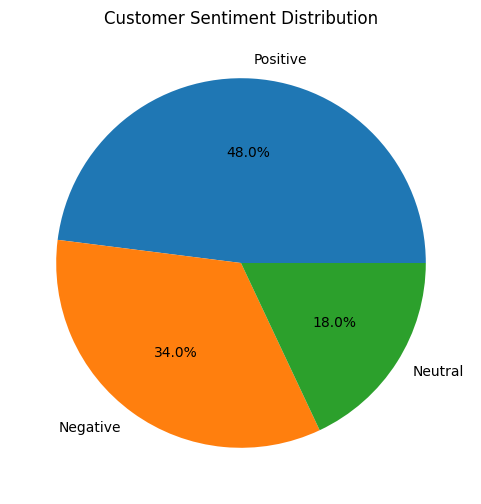

In [6]:

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Customer Sentiment Distribution")
plt.ylabel("")
plt.show()


In [7]:
issue_keywords = {

    "Delivery Delay": ["late","delay","slow","waiting"],

    "Food Quality": ["cold","stale","burnt","flavor","taste"],

    "Packaging": ["package","packaging","spill","damaged"],

    "Pricing": ["expensive","overpriced","price"],

    "Customer Service": ["staff","service","support","rude"]
}

issue_count = {}

negative_reviews = df[df["Sentiment"]=="Negative"]

for issue, keywords in issue_keywords.items():

    count = 0

    for review in negative_reviews["Clean_Review"]:

        for word in keywords:

            if word in review:
                count += 1

    issue_count[issue] = count

print("\nCommon Issues:")
print(issue_count)



Common Issues:
{'Delivery Delay': 4, 'Food Quality': 5, 'Packaging': 3, 'Pricing': 1, 'Customer Service': 3}


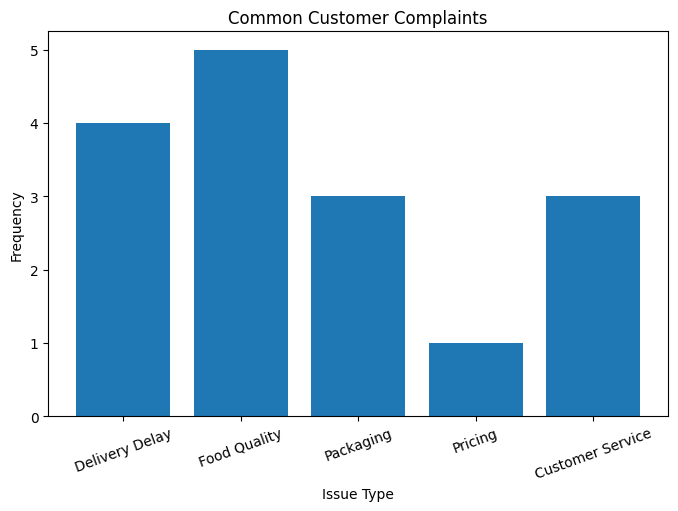

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    issue_count.keys(),
    issue_count.values()
)

plt.title("Common Customer Complaints")
plt.xlabel("Issue Type")
plt.ylabel("Frequency")

plt.xticks(rotation=20)

plt.show()

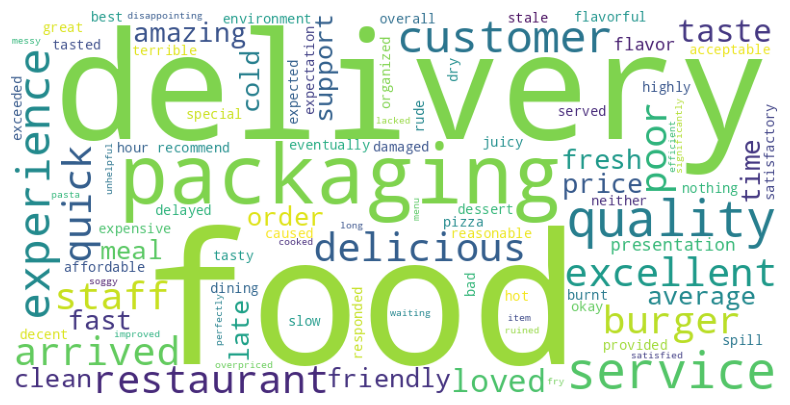

In [9]:

text = " ".join(df["Clean_Review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [10]:
total = len(df)

positive = len(df[df["Sentiment"]=="Positive"])
negative = len(df[df["Sentiment"]=="Negative"])
neutral = len(df[df["Sentiment"]=="Neutral"])

print("Total Reviews :", total)
print("Positive Reviews :", positive)
print("Negative Reviews :", negative)
print("Neutral Reviews :", neutral)

print("\nTop Issues Identified:")

for issue, count in issue_count.items():
    print(issue, ":", count)

print("\nConclusion:")
print("Customer satisfaction is generally positive.")
print("Major issues include delivery delays, food quality problems, packaging issues, pricing concerns, and customer service complaints.")

Total Reviews : 50
Positive Reviews : 24
Negative Reviews : 17
Neutral Reviews : 9

Top Issues Identified:
Delivery Delay : 4
Food Quality : 5
Packaging : 3
Pricing : 1
Customer Service : 3

Conclusion:
Customer satisfaction is generally positive.
Major issues include delivery delays, food quality problems, packaging issues, pricing concerns, and customer service complaints.


In [11]:
print(df[['Review','Sentiment']].head(10))

                                        Review Sentiment
0        The food was delicious and served hot  Positive
1           Excellent taste and quick delivery  Positive
2         Loved the packaging and food quality  Positive
3      Amazing customer service and tasty food  Positive
4       The pizza was fresh and very flavorful  Positive
5  Delivery arrived on time and food was great  Positive
6             Highly recommend this restaurant  Positive
7      Affordable prices and excellent quality  Positive
8           The burger was juicy and delicious  Positive
9             Fast delivery and friendly staff  Positive
